In [78]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [79]:
import pandas as pd
import numpy as np

In [80]:
path = ('/content/drive/MyDrive/Dataset/Wine Quality - Wine Quality.csv')
wine_quality = pd.read_csv(path)
wine_quality.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [81]:
wine_quality.shape

(6497, 13)

In [82]:
#Checking for null values
wine_quality.isnull()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,False,False,False,False,False,False,False,False,False,False,False,False,False
6493,False,False,False,False,False,False,False,False,False,False,True,False,False
6494,False,False,False,False,False,False,False,False,False,False,False,False,False
6495,False,False,False,False,False,False,False,False,False,False,False,False,False


In [83]:
wine_quality.isnull().sum()

,0
type,0
fixed acidity,18
volatile acidity,8
citric acid,3
residual sugar,2
chlorides,2
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,9


In [84]:
#Inputting values into null
wine_quality.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [85]:
wine_quality['fixed acidity'].isnull().sum()

18

In [86]:
from sklearn.impute import SimpleImputer

impute = SimpleImputer(missing_values=np.nan, strategy='mean')

impute.fit(wine_quality[['fixed acidity']])

wine_quality['fixed acidity'] = impute.transform(wine_quality[['fixed acidity']])

In [87]:
wine_quality['fixed acidity'].isnull().sum()

0

In [88]:
#Handling categorical variables
wine_quality['type'].unique()

array(['white', 'red'], dtype=object)

In [89]:
#Transforming
f_a = pd.get_dummies(wine_quality['fixed acidity'])
f_a.head()

,3.8,3.9,4.2,4.4,4.5,4.6,4.7,4.8,4.9,5.0,...,13.5,13.7,13.8,14.0,14.2,14.3,15.0,15.5,15.6,15.9
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [90]:
# Feature scaling
from sklearn.preprocessing import MinMaxScaler

MM_scaler = MinMaxScaler()

columns = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH','sulphates','alcohol', 'quality']
wine_quality[columns] = MM_scaler.fit_transform(wine_quality[columns])

wine_quality.head(10)

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,0.264463,0.126667,0.216867,0.308282,0.059801,0.152778,0.377880,0.267785,0.217054,0.129213,0.115942,0.5
1,white,0.206612,0.146667,0.204819,0.015337,0.066445,0.045139,0.290323,0.132832,0.449612,0.151685,0.217391,0.5
2,white,0.355372,0.133333,0.240964,0.096626,0.068106,0.100694,0.209677,0.154039,0.418605,0.123596,0.304348,0.5
3,white,0.280992,0.100000,0.192771,0.121166,0.081395,0.159722,0.414747,0.163678,0.364341,0.101124,0.275362,0.5
4,white,0.280992,0.100000,0.192771,0.121166,0.081395,0.159722,0.414747,0.163678,0.364341,0.101124,0.275362,0.5
5,white,0.355372,0.133333,0.240964,0.096626,0.068106,0.100694,0.209677,0.154039,0.418605,0.123596,0.304348,0.5
6,white,0.198347,0.160000,0.096386,0.098160,0.059801,0.100694,0.299539,0.150183,0.356589,0.140449,0.231884,0.5
7,white,0.264463,0.126667,0.216867,0.308282,0.059801,0.152778,0.377880,0.267785,0.217054,0.129213,0.115942,0.5
8,white,0.206612,0.146667,0.204819,0.015337,0.066445,0.045139,0.290323,0.132832,0.449612,0.151685,0.217391,0.5
9,white,0.355372,0.093333,0.259036,0.013804,0.058140,0.093750,0.283410,0.128976,0.387597,0.129213,0.434783,0.5


In [91]:
#Correlation
column = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH','sulphates','alcohol', 'quality']

wine_quality_correlation = wine_quality[column].corr()
print(wine_quality_correlation)

                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000          0.220074     0.323130   
volatile acidity           0.220074          1.000000    -0.378061   
citric acid                0.323130         -0.378061     1.000000   
residual sugar            -0.112948         -0.196702     0.142486   
chlorides                  0.298235          0.377167     0.039315   
free sulfur dioxide       -0.283360         -0.353230     0.133437   
total sulfur dioxide      -0.329721         -0.414928     0.195218   
density                    0.458286          0.271193     0.096320   
pH                        -0.251342          0.260660    -0.328689   
sulphates                  0.299847          0.225476     0.057613   
alcohol                   -0.095215         -0.038248    -0.010433   
quality                   -0.076294         -0.265953     0.085706   

                      residual sugar  chlorides  free sulfur dioxide  \
fixed acidity    

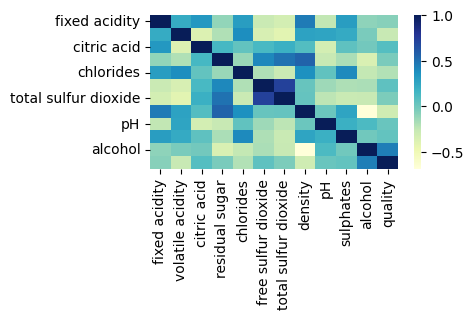

In [92]:
#Visualization
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(4,2))
sns.heatmap(wine_quality_correlation, cmap='YlGnBu')
plt.show()